In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
df=pd.read_excel("LIC_Agent_Demand.xlsx")

In [2]:
df.head()

,Agent_ID,Experience_Agent,Tenure_LIC,Agent_type,Existing_Prod_Type,Monthly_commission(Rs),Complaint_resolved,LIC_Star_rating,LastMonthCalls,CustCareScore,Agent_Bonus
0,7000000,22,4,2,3,20993,1,2,5,2,221200
1,7000001,11,2,2,4,20130,0,3,7,3,221400
2,7000002,26,4,1,4,17090,1,2,0,3,427300
3,7000003,11,10,2,3,17909,1,2,0,5,179100
4,7000004,6,10,1,3,18468,0,4,2,5,295500


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Agent_ID                500 non-null    int64
 1   Experience_Agent        500 non-null    int64
 2   Tenure_LIC              500 non-null    int64
 3   Agent_type              500 non-null    int64
 4   Existing_Prod_Type      500 non-null    int64
 5   Monthly_commission(Rs)  500 non-null    int64
 6   Complaint_resolved      500 non-null    int64
 7   LIC_Star_rating         500 non-null    int64
 8   LastMonthCalls          500 non-null    int64
 9   CustCareScore           500 non-null    int64
 10  Agent_Bonus             500 non-null    int64
dtypes: int64(11)
memory usage: 43.1 KB


In [4]:
#variable_type = pd.DataFrame({
#    "Variable": df.columns,
#    "Data Type": df.dtypes.values
#})

#variable_type
#this will make a clean table for data types

Q1 -	Identify each variable and create a visual presentation.

In [5]:
#simple data type representaion
df.dtypes


Agent_ID                  int64
Experience_Agent          int64
Tenure_LIC                int64
Agent_type                int64
Existing_Prod_Type        int64
Monthly_commission(Rs)    int64
Complaint_resolved        int64
LIC_Star_rating           int64
LastMonthCalls            int64
CustCareScore             int64
Agent_Bonus               int64
dtype: object

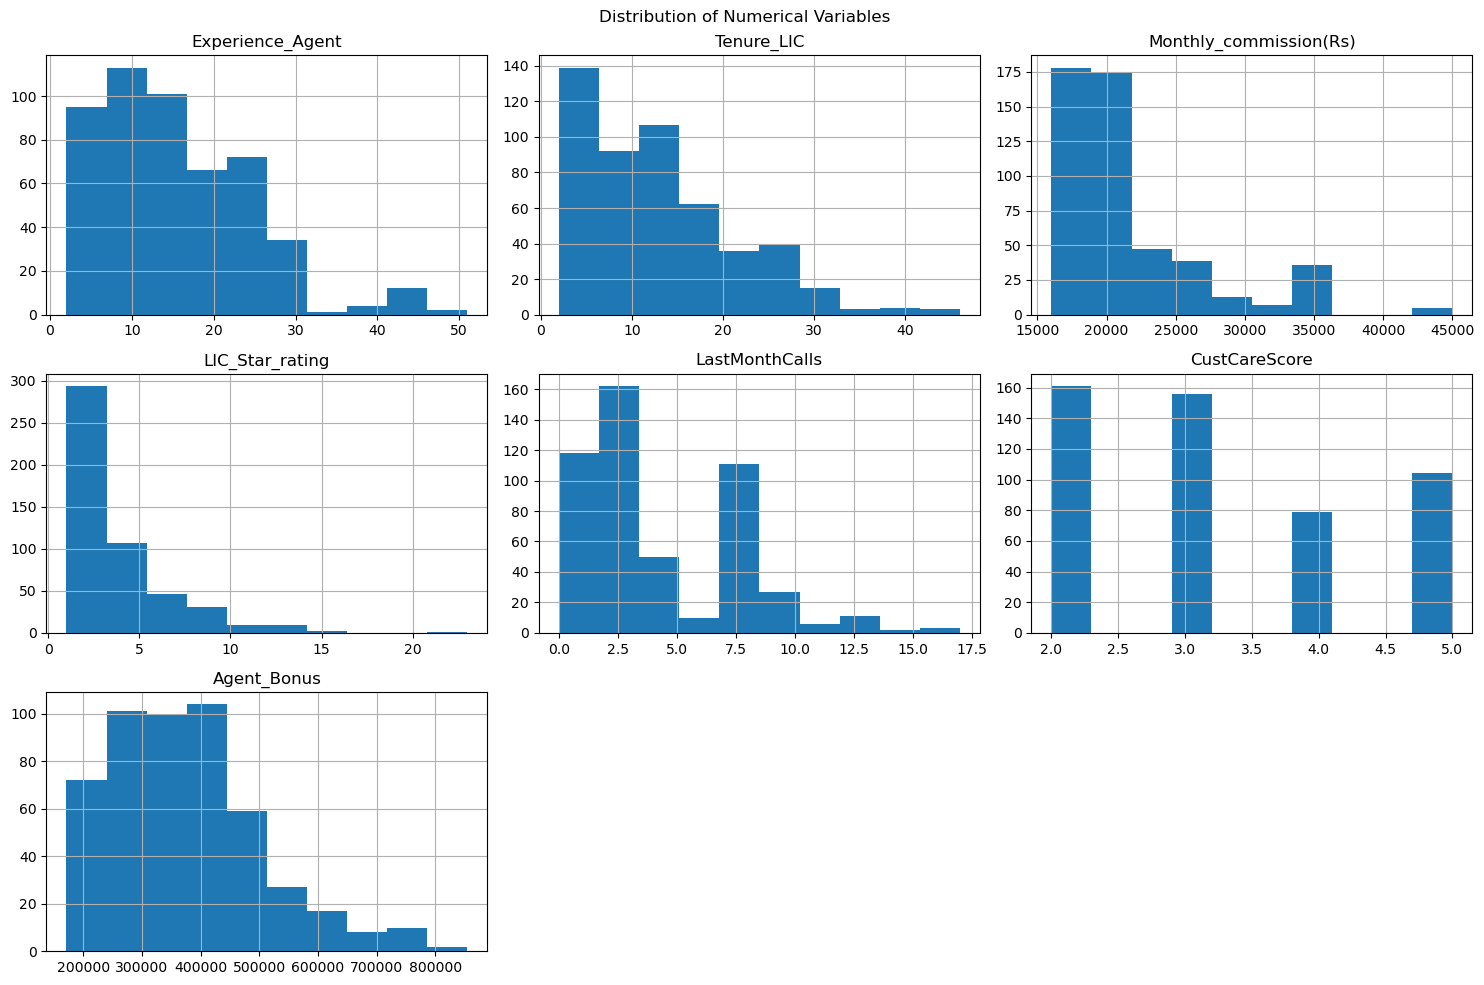

In [6]:
# Select only the numerical columns from the dataset
numerical_cols = [
    'Experience_Agent',
    'Tenure_LIC',
    'Monthly_commission(Rs)',
    'LIC_Star_rating',
    'LastMonthCalls',
    'CustCareScore',
    'Agent_Bonus'
]

# Create histograms for all numerical columns
df[numerical_cols].hist(figsize=(15,10))

# Give the graphs an overall title
plt.suptitle("Distribution of Numerical Variables")

plt.tight_layout()

plt.show()

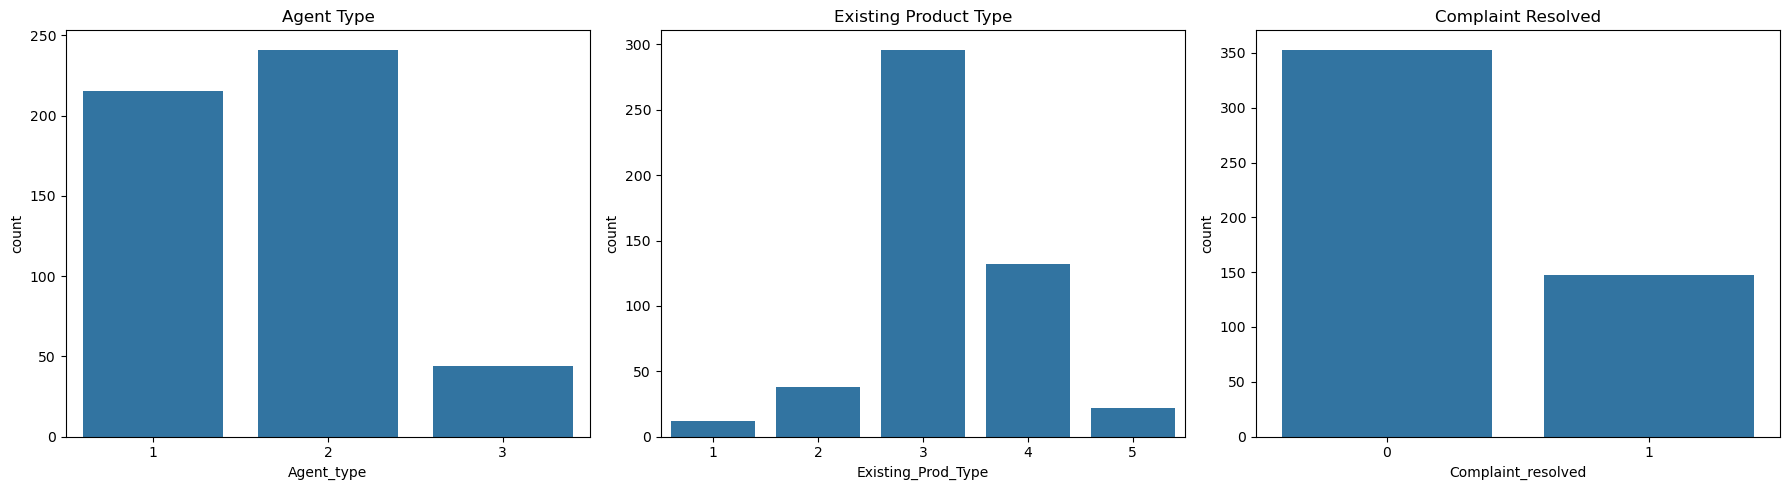

In [7]:
plt.figure(figsize=(18,5))

# Create a count plot for Agent Type
plt.subplot(1,3,1)
sns.countplot(x=df['Agent_type'])
plt.title("Agent Type")


# Create a count plot for Existing Product Type
plt.subplot(1,3,2)
sns.countplot(x=df['Existing_Prod_Type'])
plt.title("Existing Product Type")


# Create a count plot for Complaint Resolved
plt.subplot(1,3,3)
sns.countplot(x=df['Complaint_resolved'])
plt.title("Complaint Resolved")


plt.tight_layout()
plt.show()

Q2 - Find the average experience of the agent and comment on the result

In [8]:
avg_experience=df['Experience_Agent'].mean()
print("Average Experience of the agents = ",round(avg_experience,2))

Average Experience of the agents =  15.0


*********
The average experience of the LIC agents is 15 years. This indicates that, on average, the agents have nearly 15 years of experience, suggesting that the workforce is fairly experienced. A higher average experience generally reflects better product knowledge, customer handling skills, and sales expertise.
************

Q3 - Find the mean, median and mode of the Monthly_commission(Rs) and Tenure with LIC

In [9]:
#mean,median,mode of monthly commission
mean_commisions=df['Monthly_commission(Rs)'].mean()
median_commisions=df['Monthly_commission(Rs)'].median()
mode_commisions=df['Monthly_commission(Rs)'].mode()[0]#mode()[0] is used to print or consider only the first mode
print("-------------------***************----------------------")
print("")
print("monthly commission")
print("")
print("Mean = ",mean_commisions," Rs ")
print("Median = ",median_commisions," Rs ")
print("Mode = ",mode_commisions," Rs ")

print("-------------------***************----------------------")
print("")

mean_tenure=df['Tenure_LIC'].mean()
median_tenure=df['Tenure_LIC'].median()
mode_tenure=df['Tenure_LIC'].mode()[0]#mode()[0] is used to print or consider only the first mode
print("Tenure of employees in LIC")
print("")
print("Mean = ",mean_tenure," Years ")
print("Median = ",median_tenure," Years ")
print("Mode = ",mode_tenure," Years ")
print("-------------------***************----------------------")

-------------------***************----------------------

monthly commission

Mean =  21745.048  Rs 
Median =  19980.0  Rs 
Mode =  35000  Rs 
-------------------***************----------------------

Tenure of employees in LIC

Mean =  12.83  Years 
Median =  12.0  Years 
Mode =  12  Years 
-------------------***************----------------------


Q4 - Create a box plot for the Bonus amount earned and interpret your answer. Is there any outlier? 

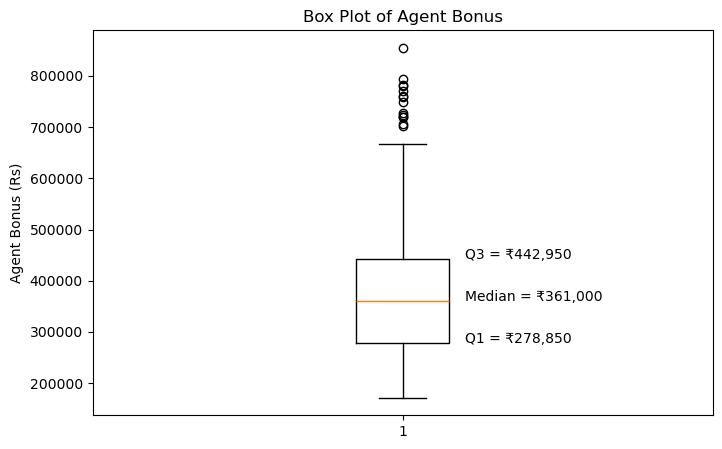

In [10]:
# Create a figure for the box plot
plt.figure(figsize=(8,5))

# Remove missing values and create the box plot
plt.boxplot(df['Agent_Bonus'].dropna())

# Calculate Q1, Median, and Q3
Q1 = df['Agent_Bonus'].quantile(0.25)
Median = df['Agent_Bonus'].median()
Q3 = df['Agent_Bonus'].quantile(0.75)

plt.text(1.1, Q1, f"Q1 = ₹{Q1:,.0f}", fontsize=10)
plt.text(1.1, Median, f"Median = ₹{Median:,.0f}", fontsize=10)
plt.text(1.1, Q3, f"Q3 = ₹{Q3:,.0f}", fontsize=10)

# Add title and Y-axis label
plt.title("Box Plot of Agent Bonus")
plt.ylabel("Agent Bonus (Rs)")

# Remove the default x-axis label '1'
#plt.xticks([])

# Display the graph
plt.show()

***********************
The box plot shows the distribution of the Agent Bonus earned by LIC agents. The median bonus is approximately ₹3.61 lakh, indicating that half of the agents earned below this value and half earned above it. The middle 50% of the bonus amounts lie between approximately ₹2.79 lakh and ₹4.43 lakh. The plot also shows several outliers above the upper whisker, indicating that a few agents received significantly higher bonuses than the majority of agents. No lower outliers are observed in the dataset.
*********************

Q5 - Create a heatmap to check the impact of each variable on Bonus amount given of the agent.

In [11]:
# Calculate the correlation between all numerical variables
correl = df.corr(numeric_only=True)

correl

,Agent_ID,Experience_Agent,Tenure_LIC,Agent_type,Existing_Prod_Type,Monthly_commission(Rs),Complaint_resolved,LIC_Star_rating,LastMonthCalls,CustCareScore,Agent_Bonus
Agent_ID,1.000000,-0.070329,-0.018879,0.000274,-0.028459,-0.040546,0.019754,0.035116,-0.093823,0.052754,-0.037211
Experience_Agent,-0.070329,1.000000,0.162823,0.088768,0.011342,0.095765,0.091408,0.099627,0.076127,0.091932,0.313144
Tenure_LIC,-0.018879,0.162823,1.000000,0.016582,0.018010,0.343525,0.011538,0.214558,0.116387,-0.007826,0.562655
Agent_type,0.000274,0.088768,0.016582,1.000000,0.063253,0.010780,0.050424,0.019262,0.051453,0.118972,0.019684
Existing_Prod_Type,-0.028459,0.011342,0.018010,0.063253,1.000000,0.013550,-0.003027,0.045438,-0.072712,0.026961,-0.029456
Monthly_commission(Rs),-0.040546,0.095765,0.343525,0.010780,0.013550,1.000000,-0.001343,0.183495,0.335565,0.034806,0.565156
Complaint_resolved,0.019754,0.091408,0.011538,0.050424,-0.003027,-0.001343,1.000000,-0.033916,0.007556,0.003756,0.034257
LIC_Star_rating,0.035116,0.099627,0.214558,0.019262,0.045438,0.183495,-0.033916,1.000000,0.074897,0.030658,0.331293
LastMonthCalls,-0.093823,0.076127,0.116387,0.051453,-0.072712,0.335565,0.007556,0.074897,1.000000,-0.043775,0.229159
CustCareScore,0.052754,0.091932,-0.007826,0.118972,0.026961,0.034806,0.003756,0.030658,-0.043775,1.000000,0.035094


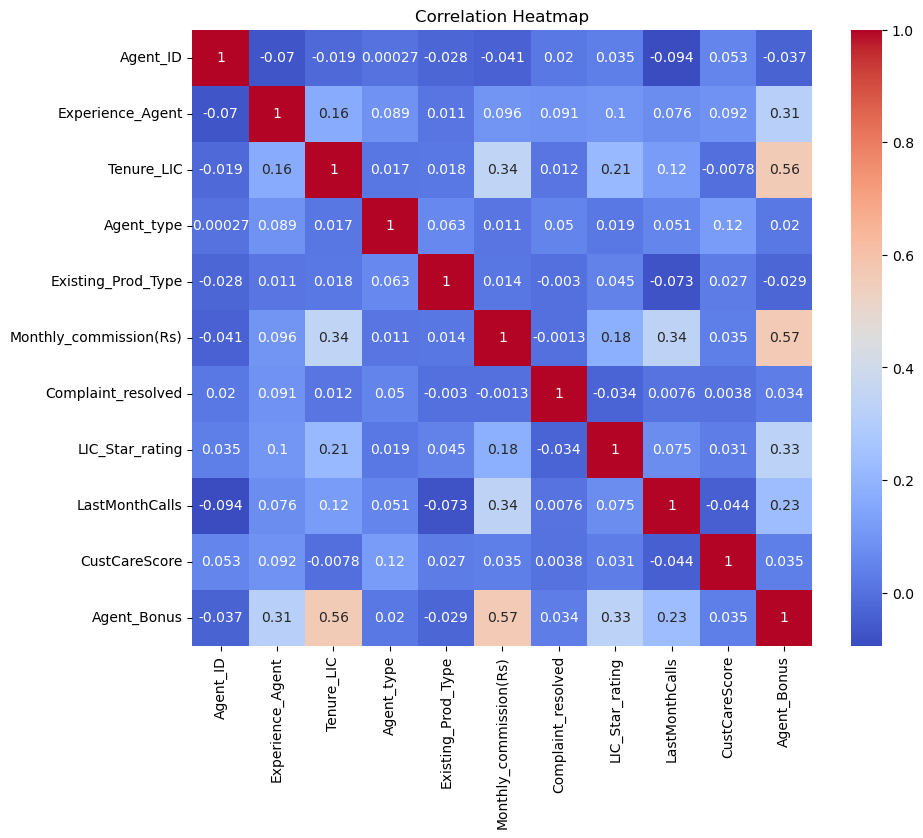

In [12]:
#heatmap
plt.figure(figsize=(10,8))
sns.heatmap(correl,annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Q6 - Find the most impactful variable among Monthly commission, Complaint resolved, LIC_Star rating, and Customer care score influencing the Bonus of the agent

In [13]:
# Display the correlation of selected variables with Agent Bonus
#print(df[['Monthly_commission(Rs)','Complaint_resolved','LIC_Star_rating','CustCareScore','Agent_Bonus']].corr(numeric_only=True))

print(correl.loc[['Monthly_commission(Rs)','Complaint_resolved','LIC_Star_rating','CustCareScore','Agent_Bonus'],['Agent_Bonus']])# loc[[rows],[columns]]

                        Agent_Bonus
Monthly_commission(Rs)     0.565156
Complaint_resolved         0.034257
LIC_Star_rating            0.331293
CustCareScore              0.035094
Agent_Bonus                1.000000


In [14]:
a=correl.loc[['Monthly_commission(Rs)','Complaint_resolved','LIC_Star_rating','CustCareScore',],['Agent_Bonus']]
print(a.idxmax(),a.max())

Agent_Bonus    Monthly_commission(Rs)
dtype: object Agent_Bonus    0.565156
dtype: float64


*******************
From the correlation analysis, Monthly Commission has the highest positive correlation (0.5656) with Agent Bonus among the selected variables. This indicates that agents who earn higher monthly commissions generally receive higher bonus amounts. Therefore, Monthly Commission is the most impactful variable influencing the Agent Bonus. LIC Star Rating has a moderate positive relationship, while Complaint Resolved and Customer Care Score have very weak positive relationships with Agent Bonus.
******************

Q7 - Create a Regression equation to predict Bonus of the agent based on Experience of the agent, Tenure with LIC and LIc Star rating. Find the bonus amount earned by an agent if an agent has 10 years of Experience, 5 years of Tenure with LIC and has 5 Star rating.

In [15]:
# Import the Linear Regression model
from sklearn.linear_model import LinearRegression

In [16]:
# Select the independent variables (inputs)
X = df[['Experience_Agent',
        'Tenure_LIC',
        'LIC_Star_rating']]

# Select the dependent variable (output)
y = df['Agent_Bonus']

In [17]:
# Create a Linear Regression model
model = LinearRegression()

# Train the model using the dataset
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [18]:
# Display the intercept (constant)
print("Intercept:", round(model.intercept_,2))

# Display the coefficients
print("Coefficients:", model.coef_)

# equation become bonus = 201500 + (2958*experience) + (7434 * Tenure) + (9111 * star rating)

Intercept: 201500.6
Coefficients: [2958.72923902 7434.39963564 9111.59159374]


In [19]:
agent=pd.DataFrame({'Experience_Agent':[10],'Tenure_LIC':[5],'LIC_Star_rating':[5]})
prediction = model.predict(agent)
print(round(prediction[0],2))

313817.85


In [20]:
Accuracy= (model.score(X,y))*100

In [21]:
print(round(Accuracy,2),"%")

40.74 %
